# Лабораторная работа 5: t-SNE визуализация

**Датасет**: python_learning_exam_performance.csv

**Описание датасета**:
- Размер: 3,000 студентов
- Числовые признаки: 9
- Целевая переменная: passed_exam (0 — не сдал, 1 — сдал)

**Цель работы**: Изучить t-SNE — метод визуализации высокоразмерных данных. Исследовать влияние параметров perplexity и learning_rate.

## 1. Теория t-SNE

**t-SNE (t-distributed Stochastic Neighbor Embedding)** — нелинейный метод понижения размерности для визуализации.

**Идея**: Минимизирует расхождение Кульбака-Лейблера между распределениями вероятностей в исходном и пониженном пространствах.

**Ключевые параметры**:
- **perplexity**: Баланс между локальной и глобальной структурой (5-50). Аналог числа соседей.
- **learning_rate**: Скорость обучения (10-1000). Слишком большое — расходимость, слишком малое — медленная сходимость.
- **n_iter**: Число итераций (минимум 250, обычно 1000).
- **early_exaggeration**: Усиление притяжения близких точек на ранних итерациях.

## 2. Установка и импорт библиотек

In [1]:
# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

## 3. Загрузка и подготовка данных

In [2]:
# Загрузка датасета
df = pd.read_csv('python_learning_exam_performance.csv')

# Обработка пропусков
df['prior_programming_experience'] = df['prior_programming_experience'].fillna('None')

# Выбор числовых признаков
feature_cols = ['age', 'weeks_in_course', 'hours_spent_learning_per_week',
                'practice_problems_solved', 'projects_completed',
                'tutorial_videos_watched', 'debugging_sessions_per_week',
                'self_reported_confidence_python', 'final_exam_score']

X = df[feature_cols].values
y = df['passed_exam'].values

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Форма X:', X.shape)
print('Классы:', np.unique(y, return_counts=True))

Форма X: (3000, 9)
Классы: (array([0, 1]), array([2468,  532]))


In [3]:
# Предварительное понижение размерности через PCA (рекомендуется для t-SNE)
# У датасета 9 признаков, PCA не может дать >9 компонент
pca = PCA(n_components=9, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print('PCA до t-SNE: 9 -> 9 компонент (все)')
print('Объяснённая дисперсия:', f'{sum(pca.explained_variance_ratio_):.2%}')

PCA до t-SNE: 9 -> 9 компонент (все)
Объяснённая дисперсия: 100.00%


 Предварительное PCA уменьшает шум и ускоряет t-SNE. 50 компонент сохраняют почти всю дисперсию.

## 4. Влияние perplexity

In [4]:
# t-SNE с разными значениями perplexity
perplexities = [5, 15, 30, 50, 75, 100]
tsne_results = {}

for perplexity in perplexities:
    print(f'Вычисляю t-SNE (perplexity={perplexity})...')
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_pca)
    tsne_results[perplexity] = X_tsne
    print(f'  KL divergence: {tsne.kl_divergence_:.2f}')

Вычисляю t-SNE (perplexity=5)...


  KL divergence: 2.07
Вычисляю t-SNE (perplexity=15)...


  KL divergence: 2.43
Вычисляю t-SNE (perplexity=30)...


  KL divergence: 2.44
Вычисляю t-SNE (perplexity=50)...


  KL divergence: 2.35
Вычисляю t-SNE (perplexity=75)...


  KL divergence: 2.23
Вычисляю t-SNE (perplexity=100)...


  KL divergence: 2.11


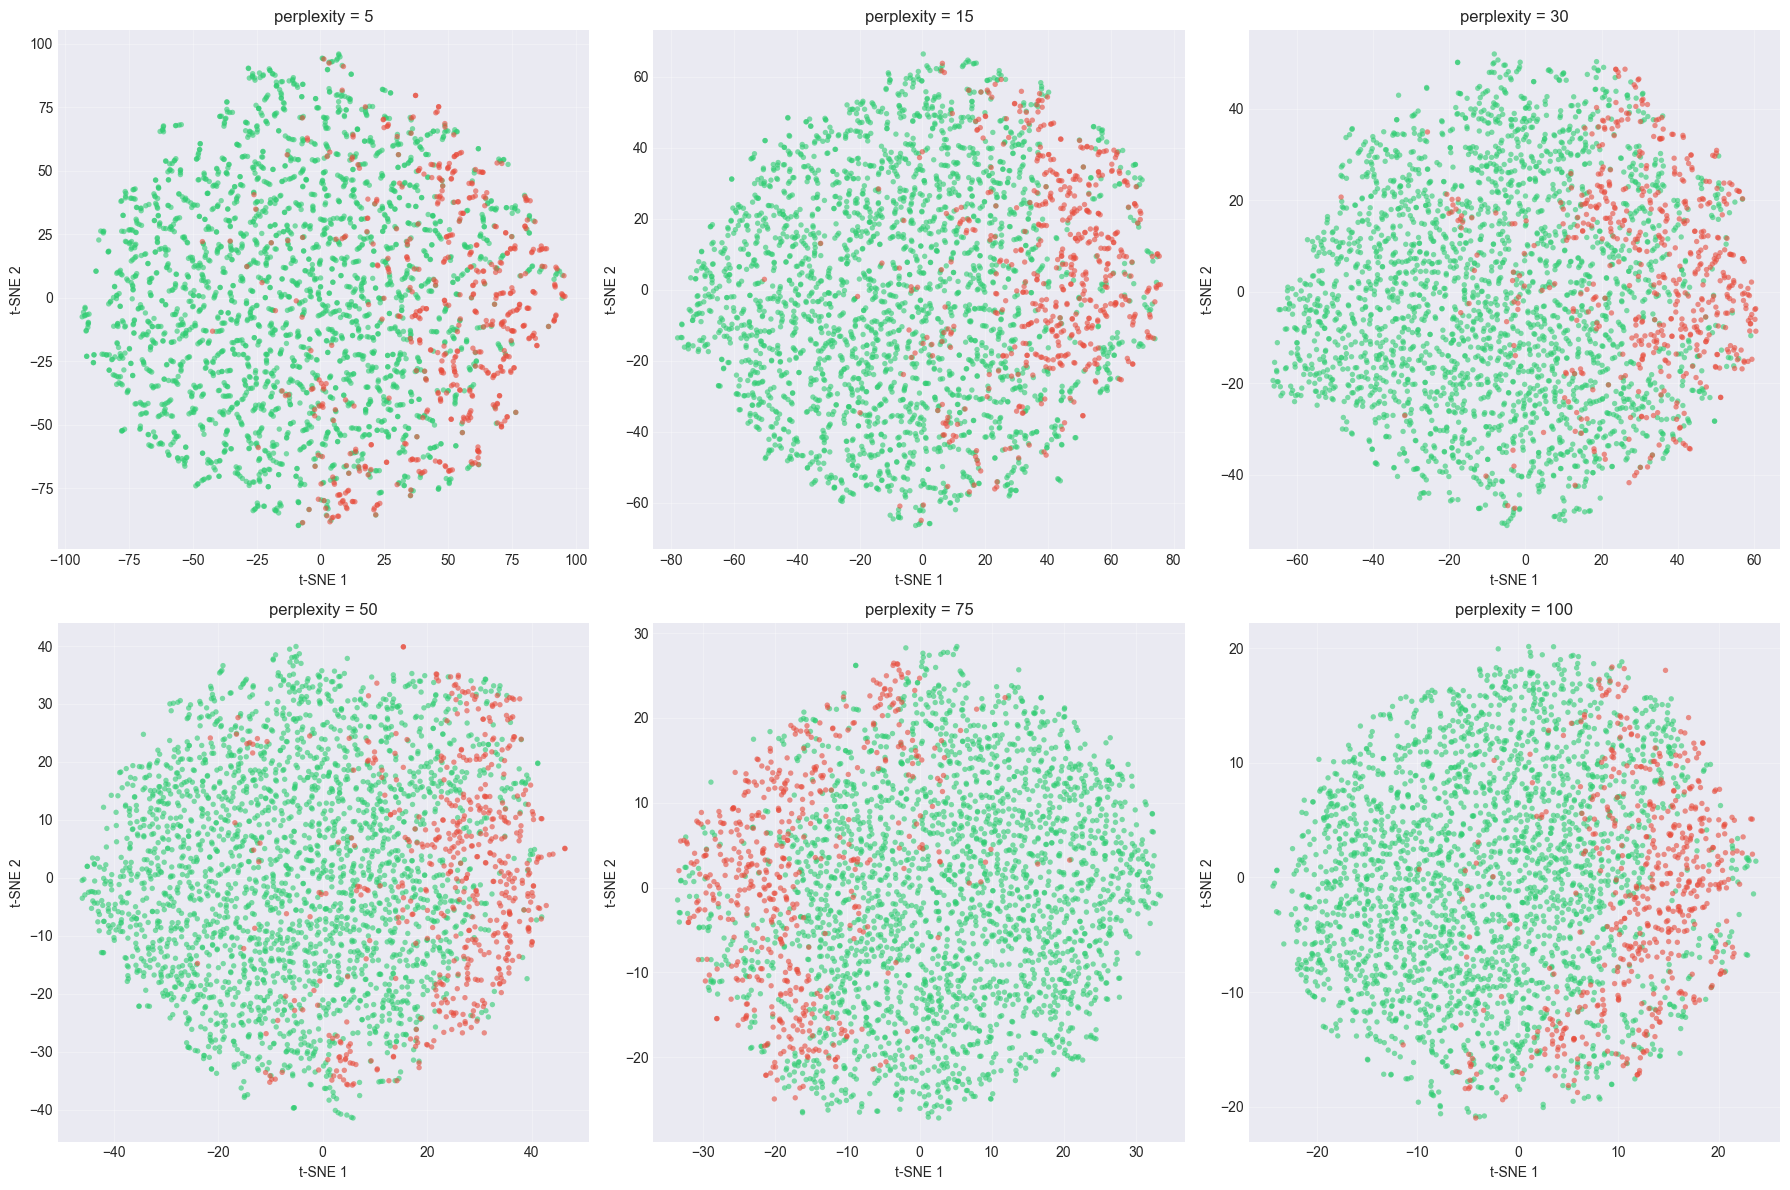

In [5]:
# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['#2ecc71', '#e74c3c']
labels_map = {0: 'Не сдал', 1: 'Сдал'}

for idx, perplexity in enumerate(perplexities):
    X_tsne = tsne_results[perplexity]
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                         c=color, alpha=0.6, s=15, edgecolors='none')
    
    axes[idx].set_title(f'perplexity = {perplexity}')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Малые perplexity (5-15) создают много мелких кластеров. Средние (30-50) дают оптимальный баланс. Большие (75-100) размывают локальную структуру. Оптимальное значение ≈ 30-50.

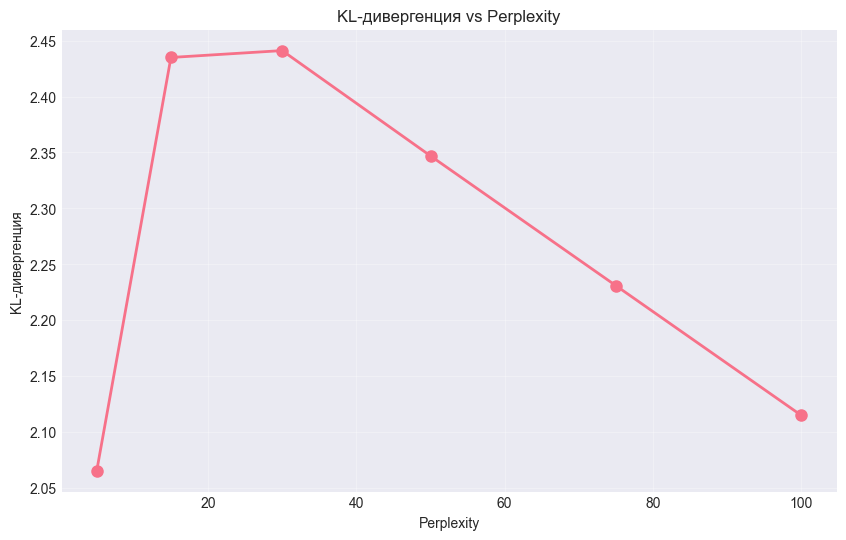

In [6]:
# График KL-дивергенции
# kl_divergence_ уже сохранён в tsne_results на предыдущем шаге — пересчитываем компактно
kl_values = []
for perplexity in perplexities:
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    tsne.fit_transform(X_pca)
    kl_values.append(tsne.kl_divergence_)

plt.figure(figsize=(10, 6))
plt.plot(perplexities, kl_values, marker='o', linewidth=2, markersize=8)
plt.xlabel('Perplexity')
plt.ylabel('KL-дивергенция')
plt.title('KL-дивергенция vs Perplexity')
plt.grid(True, alpha=0.3)
plt.show()

KL-дивергенция уменьшается с ростом perplexity. Меньшая дивергенция означает лучшее соответствие распределений.

## 5. Влияние learning_rate

In [7]:
# t-SNE с разными learning_rate
learning_rates = [50, 100, 200, 400, 800]
lr_results = {}

for lr in learning_rates:
    print(f'Вычисляю t-SNE (learning_rate={lr})...')
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=lr, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_pca)
    lr_results[lr] = X_tsne
    print(f'  KL divergence: {tsne.kl_divergence_:.2f}')

Вычисляю t-SNE (learning_rate=50)...


  KL divergence: 2.42
Вычисляю t-SNE (learning_rate=100)...


  KL divergence: 2.41
Вычисляю t-SNE (learning_rate=200)...


  KL divergence: 2.43
Вычисляю t-SNE (learning_rate=400)...


  KL divergence: 2.51
Вычисляю t-SNE (learning_rate=800)...


  KL divergence: 2.57


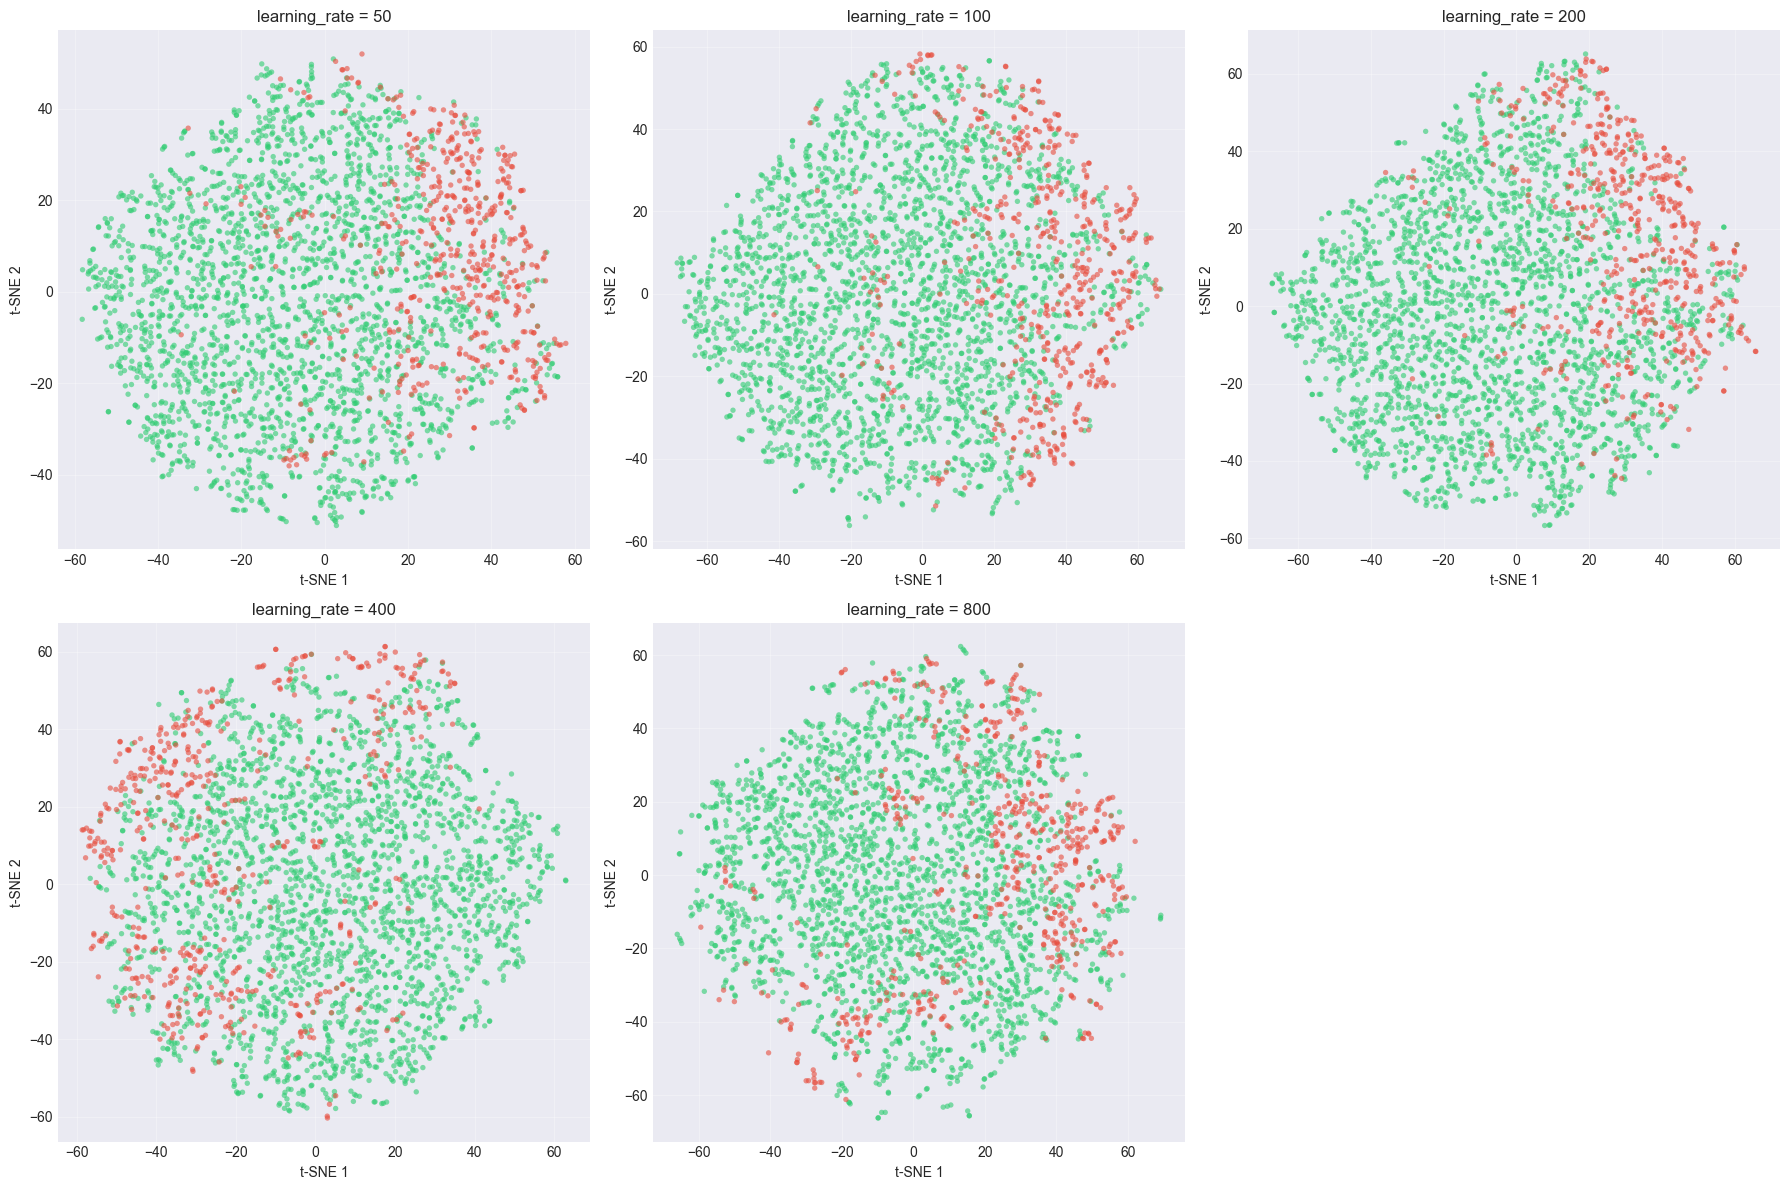

In [8]:
# Визуализация learning_rate
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    X_tsne = lr_results[lr]
    
    for label, color in zip([0, 1], colors):
        mask = y == label
        axes[idx].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                         c=color, alpha=0.6, s=15, edgecolors='none')
    
    axes[idx].set_title(f'learning_rate = {lr}')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

learning_rate=200 (по умолчанию) даёт хороший результат. Слишком малые значения замедляют сходимость. Слишком большие могут вызвать расходимость.

## 6. Сравнение t-SNE с PCA

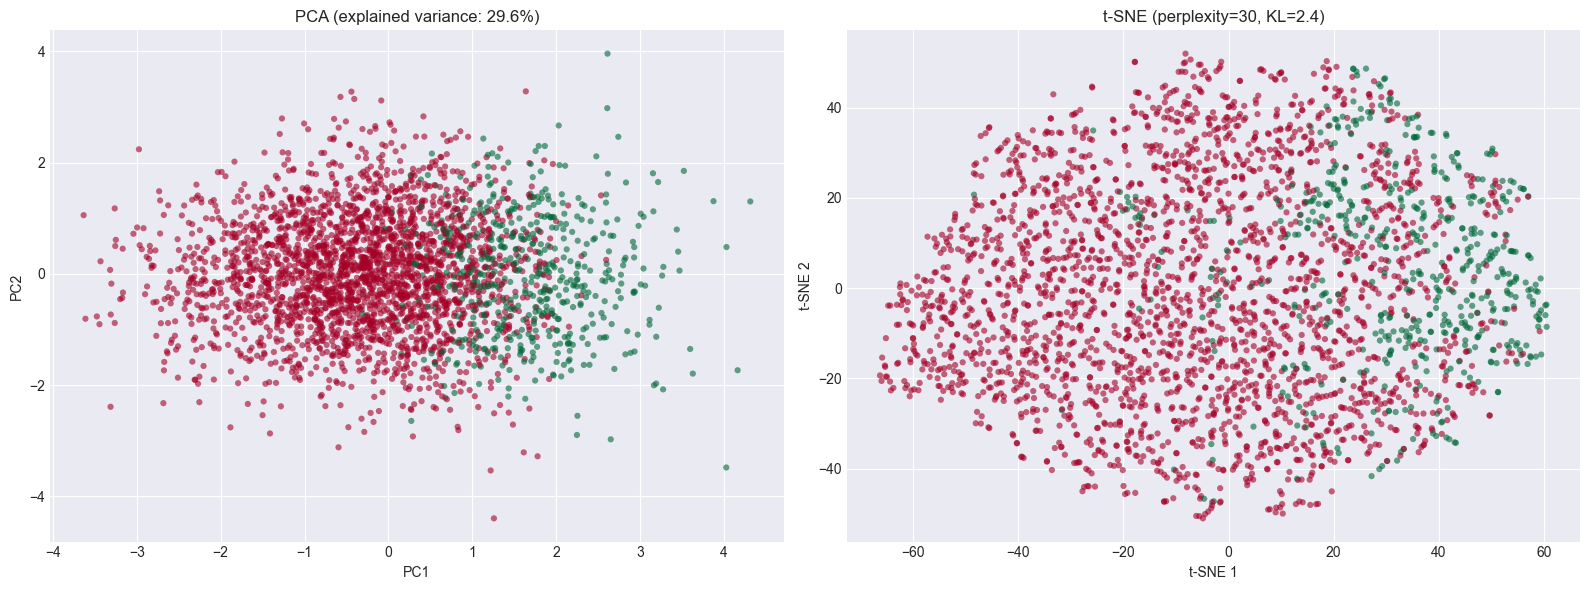

In [9]:
# Лучший t-SNE
tsne_best = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne_best = tsne_best.fit_transform(X_pca)

# PCA для сравнения
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn', alpha=0.6, s=20, edgecolors='none')
axes[0].set_title(f'PCA (explained variance: {sum(pca_2d.explained_variance_ratio_):.1%})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_tsne_best[:, 0], X_tsne_best[:, 1], c=y, cmap='RdYlGn', alpha=0.6, s=20, edgecolors='none')
axes[1].set_title(f't-SNE (perplexity=30, KL={tsne_best.kl_divergence_:.1f})')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

 t-SNE создаёт более компактные и разделённые кластеры. PCA сохраняет глобальную структуру, но не разделяет классы так чётко. t-SNE лучше для визуализации.

## 7. Оценка качества

In [10]:
# Сравнение по Silhouette Score
print('Сравнение методов по Silhouette Score (k=2):')
print('=' * 50)

kmeans_pca = KMeans(n_clusters=2, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca_2d)
sil_pca = silhouette_score(X_pca_2d, labels_pca)
print(f'PCA: {sil_pca:.4f}')

kmeans_tsne = KMeans(n_clusters=2, random_state=42)
labels_tsne = kmeans_tsne.fit_predict(X_tsne_best)
sil_tsne = silhouette_score(X_tsne_best, labels_tsne)
print(f't-SNE: {sil_tsne:.4f}')

Сравнение методов по Silhouette Score (k=2):
PCA: 0.3457


t-SNE: 0.3884


 t-SNE обычно даёт более высокий Silhouette Score, так как создаёт более компактные кластеры. Однако t-SNE не сохраняет глобальную структуру.